### Importing the data

I imported the data manually because I wanted to try it out, but you could just use something like pytorch instead to import the data and use it. I have added the code I used to import the data here.

I would also like to declare that the code in the first 2 blocks are not mine, I used it from kaggle.

In [1]:
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test) 

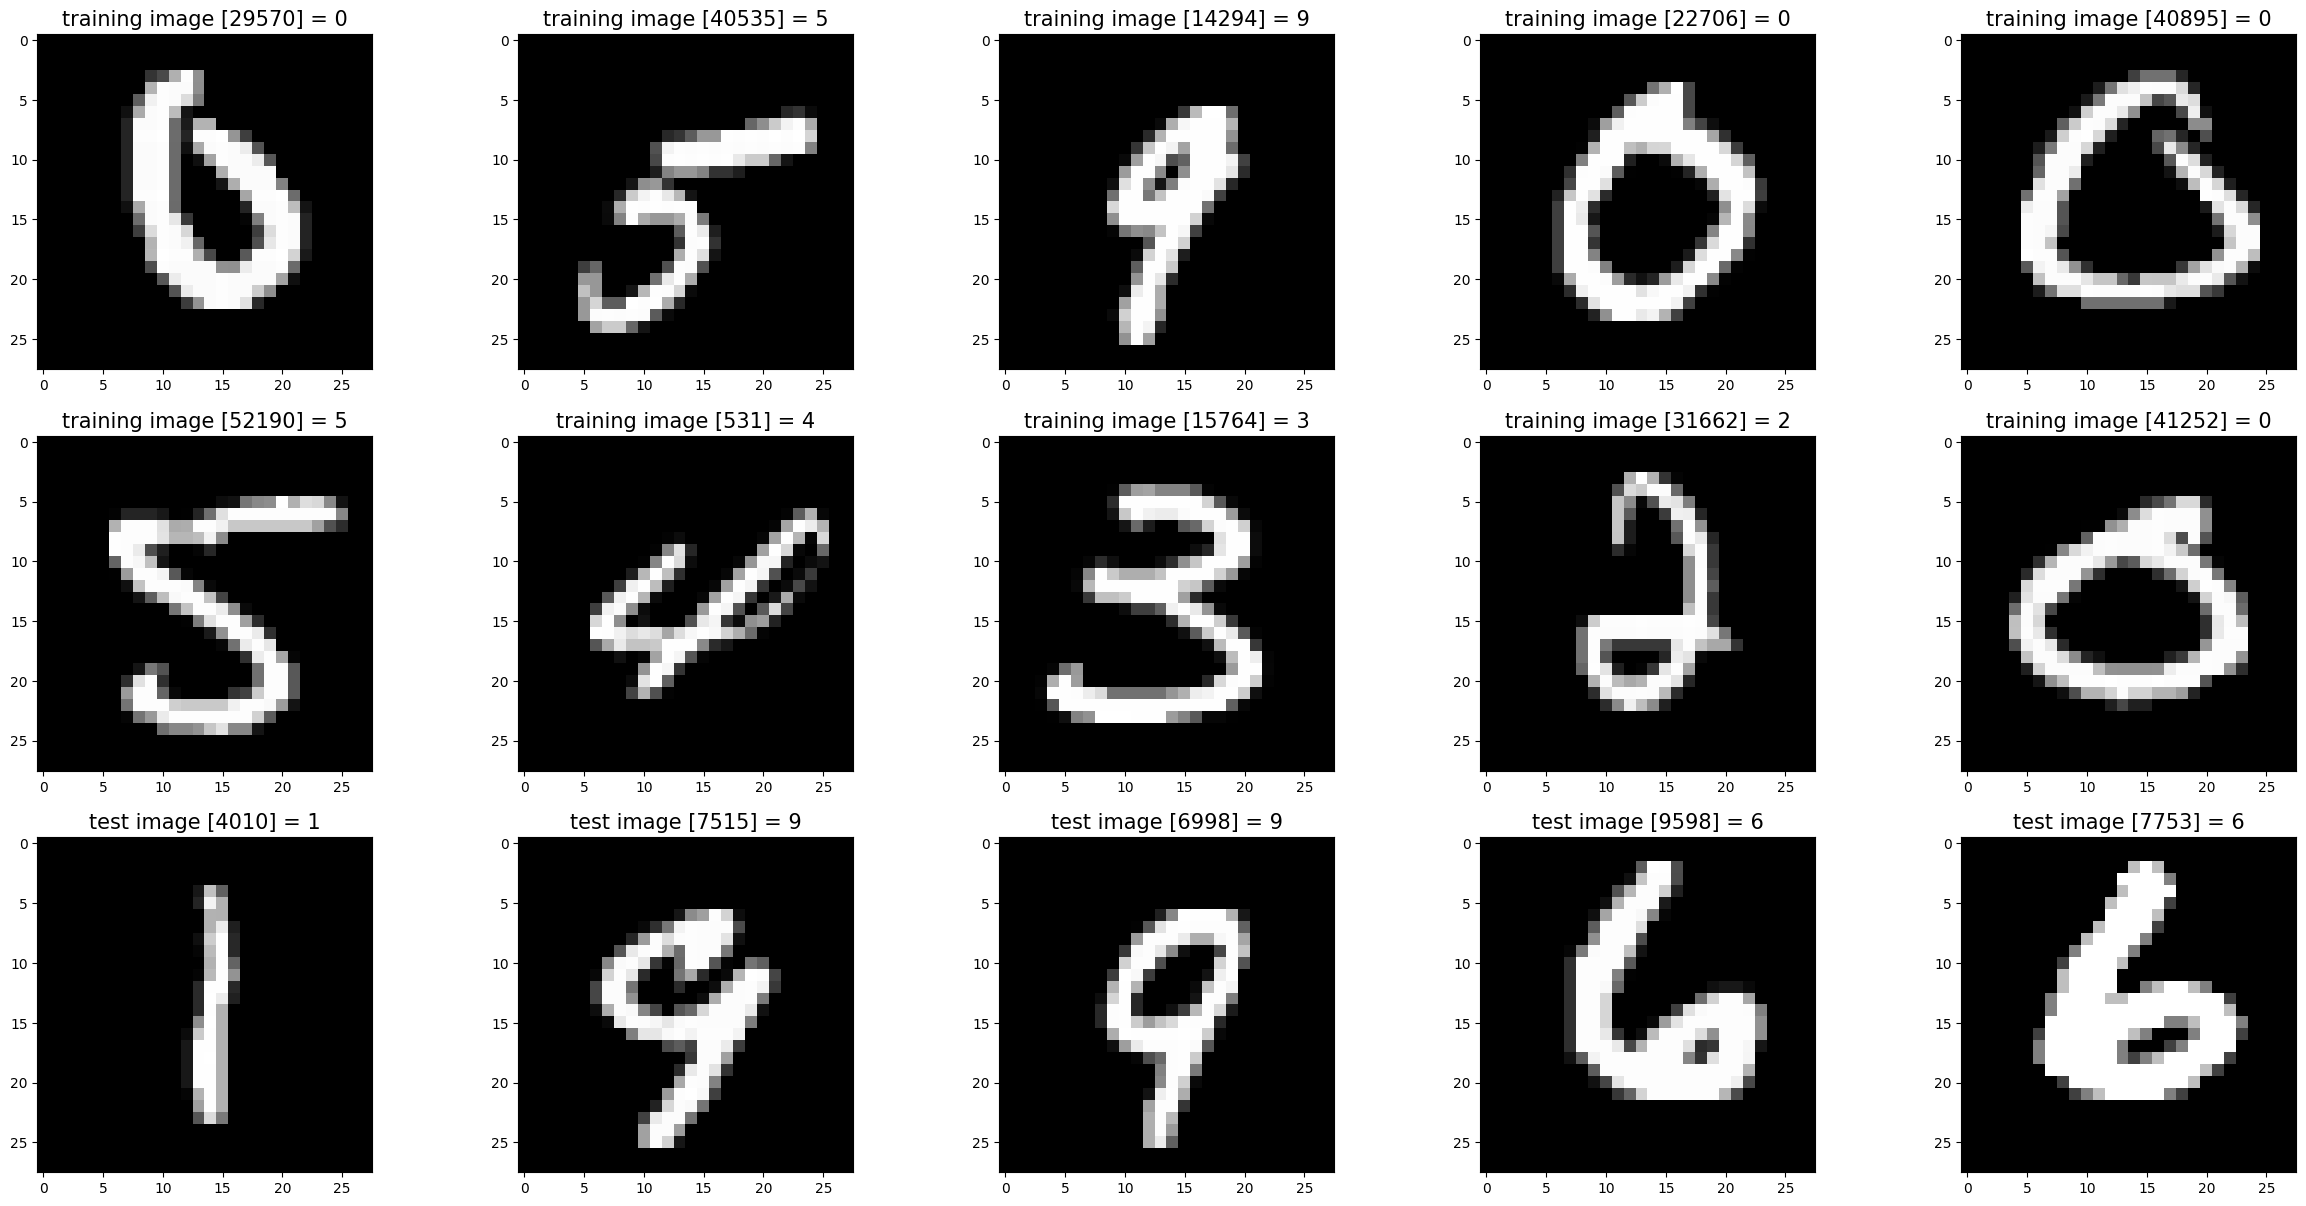

In [2]:
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'data/'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [ ]:
import cupy as np
np.random.seed(0)
np._default_memory_pool.free_all_blocks()

#Convert the data into np arrays
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

# Flatten all images at once
real_x_train = x_train.reshape(x_train.shape[0], -1)
real_x_test = x_test.reshape(x_test.shape[0], -1) 

# Transpose once for NN
x_train1 = real_x_train.T
x_test1 = real_x_test.T  

print(x_train1.shape)
print(x_test1.shape)  

(784, 60000)
(784, 10000)


### A simple single hidden layer neural network

These were my baby steps. Here, figuring out the mathematics behind neural networks was my goal, rather than creating code that I could reuse or expand

In [ ]:
# Initialise the parameters
def initialise_parameters():
    W1 = np.random.randn(10,784) * 0.01
    b1 = np.random.randn(10,1) 
    W2 = np.random.randn(10,10) * 0.01
    b2 = np.random.randn(10,1) 

    return W1, W2, b1, b2

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)  # subtract column max
    exp_Z = np.exp(Z_shift)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def ReLU(Z):
    return np.maximum(0, Z)

def ReLU_derivative(Z):
    return Z > 0

def one_hot(Y):
    Y = np.array(Y).astype(int)
    num_classes = int(Y.max().item()) + 1  # Convert CuPy scalar to Python int
    one_hot_Y = np.zeros((Y.size, num_classes))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def forward_propagation(W1, b1, W2, b2, X):
    Z1 = np.dot(W1, X) + b1
    A1 = ReLU(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def backward_propagation(Z1, A1, W2, A2, X, Y):
    m = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, 1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * ReLU_derivative(Z1)
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, 1, keepdims=True)
    return dW1, db1, dW2, db2

def update_parameters(W1, W2, b1, b2, dW1, dW2, db1, db2, alpha):
    W1 = W1 - alpha * dW1
    W2 = W2 - alpha * dW2
    b1 = b1 - alpha * db1
    b2 = b2 - alpha * db2
    return W1, W2, b1, b2

def prediction(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, W2, b1, b2 = initialise_parameters()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_propagation(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_propagation(Z1, A1, W2, A2, X, Y)
        W1, W2, b1, b2 = update_parameters(W1, W2, b1, b2, dW1, dW2, db1, db2, alpha)
        if i % 10 == 0:
            predictions = prediction(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [29]:
W1, b1, W2, b2 = gradient_descent(x_train1, y_train, 0.000805, 500)

0.0676
0.2569166666666667
0.4633333333333333
0.5891
0.6756333333333333
0.7211333333333333
0.7491833333333333
0.7688333333333334
0.784
0.79775
0.80925
0.8211666666666667
0.8301166666666666
0.8376833333333333
0.82905
0.8285
0.8465
0.8568333333333333
0.8630833333333333
0.8672666666666666
0.8702
0.8724833333333334
0.8750666666666667
0.8771833333333333
0.8793666666666666
0.88085
0.88255
0.8842166666666667
0.8856166666666667
0.8868166666666667
0.88775
0.8888833333333334
0.8898333333333334
0.89075
0.8917166666666667
0.8924
0.8931333333333333
0.8940833333333333
0.8949
0.89545
0.8962833333333333
0.8969333333333334
0.8977
0.8982666666666667
0.8987666666666667
0.8993
0.89995
0.9001833333333333
0.9007333333333334
0.9012333333333333


### Generalising the Neural Network for any layer, size, and activation function

I wanted to try generalising it to n layers, as that would require a bit more of the grasp that I felt was missing, and additionally I made the size of each of the layers variables.

In [35]:
class NeuralNetwork():
    def __init__(self, alpha, size : list =[10], input_size=28*28, layers=1, output_size=10):
        size.insert(0, input_size) 
        size.append(output_size)
        self.W = []
        self.b = []
        for i in range(layers+1):
            Wi = np.random.randn(size[i+1], size[i]) * 0.01
            bi = np.random.randn(size[i+1], 1)
            self.W.append(Wi)
            self.b.append(bi)
        self.alpha = alpha
        self.test = []

    def forward_propagation(self, X):
        self.Z = []
        self.A = []
        for i in range(len(self.W)):
            Zi = np.dot(self.W[i], X) + self.b[i] if i == 0 else np.dot(self.W[i], self.A[i-1]) + self.b[i]
            self.Z.append(Zi)
            Ai = softmax(self.Z[i]) if i == len(self.W) - 1 else ReLU(self.Z[i])
            self.A.append(Ai)
        return self.A[-1]

    
    def backward_propagation(self, X, Y):
        m = X.shape[1]
        one_hot_Y = one_hot(Y)
        self.dZ = []
        self.dW = []
        self.db = []
        for i in range(len(self.A)):
            dZi = self.A[-(i+1)] - one_hot_Y if i == 0 else np.dot(self.W[-i].T, self.dZ[i-1]) * ReLU_derivative(self.Z[-(i+1)])
            self.dZ.append(dZi)
            dWi = 1/m * np.dot(self.dZ[i], self.A[-(i+2)].T) if i + 2 <= len(self.A) else 1/m * np.dot(self.dZ[i], X.T)
            self.dW.append(dWi)
            dbi = 1/m * np.sum(self.dZ[i], 1, keepdims=True)
            self.db.append(dbi)
        self.dZ.reverse()
        self.dW.reverse()
        self.db.reverse()
    
    def update_parameters(self):
        for i in range(len(self.W)):
            self.W[i] = self.W[i] - self.alpha * self.dW[i]
            self.b[i] = self.b[i] - self.alpha * self.db[i]

    def predict(self, X):
        A2 = self.forward_propagation(X)
        return np.argmax(A2, axis=0)
    
    def accuracy(self, X, Y):
        preds = self.predict(X)
        return np.mean(preds == Y)

In [36]:
nn = NeuralNetwork(size=[128], alpha=0.0052)
batch_size = 256
epochs = 41
for epoch in range(epochs):
    for i in range(0, x_train1.shape[1], batch_size):
        X_batch = x_train1[:, i:i+batch_size]
        Y_batch = y_train[i:i+batch_size]
        nn.forward_propagation(X_batch)
        nn.backward_propagation(X_batch, Y_batch)
        nn.update_parameters()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}: train acc = {nn.accuracy(x_train1, y_train):.4f}")

print(nn.accuracy(x_test1, y_test))

Epoch 0: train acc = 0.9018
Epoch 5: train acc = 0.9686
Epoch 10: train acc = 0.9836
Epoch 15: train acc = 0.9900
Epoch 20: train acc = 0.9927
Epoch 25: train acc = 0.9941
Epoch 30: train acc = 0.9960
Epoch 35: train acc = 0.9974
Epoch 40: train acc = 0.9984
0.9728


### Implementing the Adam Optimizer

Additionally, the activation function used in each of the layers is now a variable

In [37]:
def softmax(Z, derivative : bool = 0):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)  # subtract column max
    exp_Z = np.exp(Z_shift)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True) if not derivative else 1

def ReLU(Z, derivative : bool = 0):
    return np.maximum(0, Z) if not derivative else Z > 0

def sigmoid(Z, derivative : bool = 0):
    return 1/(1+np.exp(-Z)) if not derivative else np.exp(-Z)*sigmoid(Z)**2

def tanh(Z, derivative : bool = 0):
    return 2*sigmoid(2*Z) - 1 if not derivative else 4*sigmoid(2*Z, 1)

def LeakyReLU(Z, a=0.01, derivative : bool = 0):
    return np.where(Z > 0, Z, a * Z) if not derivative else np.where(Z > 0, 1, a)

activation_functions = {
    "relu" : ReLU,
    "leakyrelu" : LeakyReLU,
    "tanh" : tanh,
    "sigmoid" : sigmoid,
    "softmax" : softmax,
}

In [38]:
class NeuralNetwork():
    def __init__(self, alpha, activation: list = [], size : list =[10], input_size=28*28, layers=1, output_size=10):
        size.insert(0, input_size)
        size.append(output_size)
        self.t = 0
        self.beta_1 = 0.01
        self.beta_2 = 0.01
        self.W = []
        self.b = []
        self.m = []
        self.v = []
        self.m_hat = []
        self.v_hat = []
        for i in range(layers+1):
            Wi = np.random.randn(size[i+1], size[i]) * np.sqrt(2 / size[i])
            mi = np.zeros((size[i+1], size[i]))
            vi = np.zeros((size[i+1], size[i]))
            bi = np.zeros((size[i+1], 1))  
            self.W.append(Wi)
            self.m.append(mi)
            self.v.append(vi)
            self.m_hat.append(mi)
            self.v_hat.append(vi)
            self.b.append(bi)
        self.alpha = alpha
        
        if activation is None or len(activation) == 0:
            self.activation = ["relu"] * (layers) + ["softmax"]
        else:
            self.activation = activation
            if len(self.activation) < layers + 1:
                self.activation += ["relu"] * (layers - len(self.activation) - 1)
                self.activation.append("softmax")
            self.activation[-1] = "softmax"  
            
    def forward_propagation(self, X):
        self.Z = []
        self.A = []
        for i in range(len(self.W)):
            Zi = np.dot(self.W[i], X) + self.b[i] if i == 0 else np.dot(self.W[i], self.A[i-1]) + self.b[i]
            self.Z.append(Zi)
            Ai = activation_functions[self.activation[i]](self.Z[i])
            self.A.append(Ai)
        return self.A[-1]

    
    def backward_propagation(self, X, Y):
        self.t += 1
        m = X.shape[1]
        one_hot_Y = one_hot(Y)
        self.dZ = []
        self.dW = []
        self.db = []
        for i in range(len(self.A)):
            dZi = self.A[-(i+1)] - one_hot_Y if i == 0 else np.dot(self.W[-i].T, self.dZ[i-1]) * activation_functions[self.activation[-(i+1)]](self.Z[-(i+1)], 1)
            self.dZ.append(dZi)
            dWi = 1/m * np.dot(self.dZ[i], self.A[-(i+2)].T) if i + 2 <= len(self.A) else 1/m * np.dot(self.dZ[i], X.T)
            self.m[-(i+1)] = self.beta_1 * self.m[-(i+1)] + (1 - self.beta_1) * dWi
            self.v[-(i+1)] = self.beta_2 * self.v[-(i+1)] + (1 - self.beta_2) * dWi ** 2
            self.m_hat[-(i+1)] = (self.m[-(i+1)]) / (1 - self.beta_1 ** self.t)
            self.v_hat[-(i+1)] = (self.v[-(i+1)]) / (1 - self.beta_2 ** self.t)
            self.dW.append(dWi)
            dbi = 1/m * np.sum(self.dZ[i], 1, keepdims=True)
            self.db.append(dbi)
        self.dZ.reverse()
        self.dW.reverse()
        self.db.reverse()
    
    def update_parameters(self):
        for i in range(len(self.W)):
            self.W[i] = self.W[i] - self.alpha * self.m_hat[i] / (np.sqrt(self.v_hat[i]) + 1e-8)
            self.b[i] = self.b[i] - self.alpha * self.db[i]

    def predict(self, X):
        A2 = self.forward_propagation(X)
        return np.argmax(A2, axis=0)
    
    def accuracy(self, X, Y):
        preds = self.predict(X)
        return np.mean(preds == Y)

In [39]:
nn3 = NeuralNetwork(size=[100, 100], layers=2, alpha=0.001)
batch_size = 256
epochs = 41 
for epoch in range(epochs):
    for i in range(0, x_train1.shape[1], batch_size):
        X_batch = x_train1[:, i:i+batch_size]
        Y_batch = y_train[i:i+batch_size]
        nn3.forward_propagation(X_batch)
        nn3.backward_propagation(X_batch, Y_batch)
        nn3.update_parameters()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}: train acc = {nn3.accuracy(x_train1, y_train):.4f}")

print(nn3.accuracy(x_test1, y_test))

Epoch 0: train acc = 0.9050
Epoch 5: train acc = 0.9587
Epoch 10: train acc = 0.9771
Epoch 15: train acc = 0.9790
Epoch 20: train acc = 0.9840
Epoch 25: train acc = 0.9820
Epoch 30: train acc = 0.9890
Epoch 35: train acc = 0.9914
Epoch 40: train acc = 0.9910
0.9677
